# Consigna de la práctica

El siguiente código genera una señal (hipótesis) binaria compleja que permite modificar, a través de la variable "ref", la probabilidad de ocurrencia de los valores binarios: 

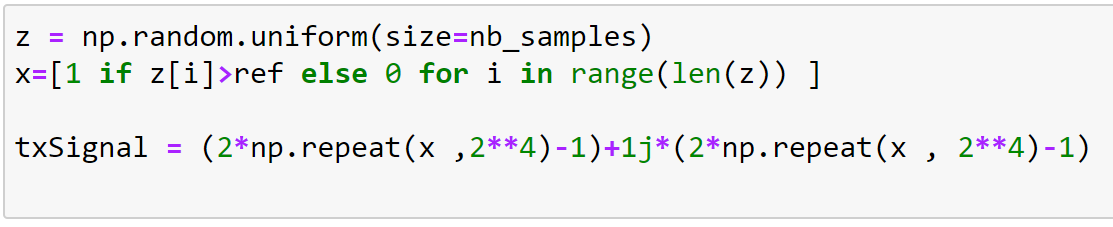

Inicialmente configure el valor de la variable "ref" a un valor de 0.5.

**1.** Realizar  un gráfica temporal  y el histograma de cada una de las componentes de la señal. Realizar también una gráfica en frecuencia. Describa con sus propias palabras lo que observa de las gráficas.
Considerando la siguiente configuración del SDR:

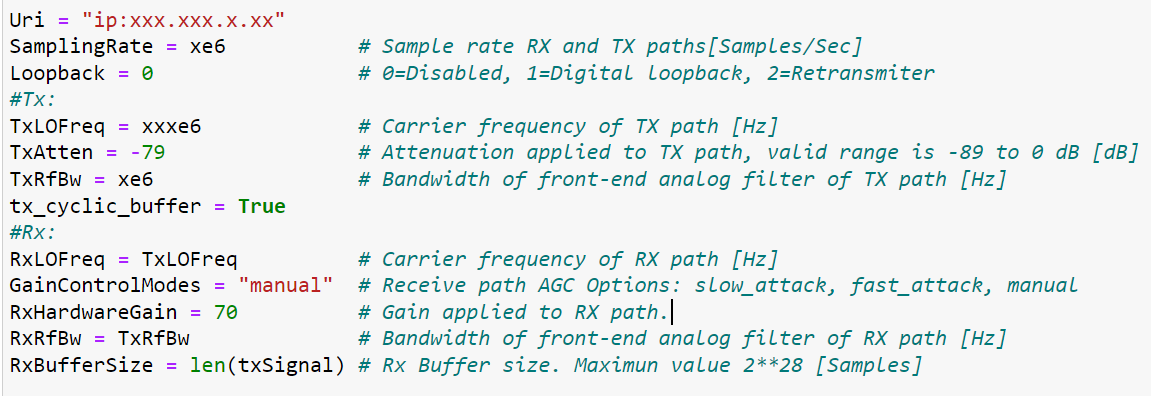


**2.** Realice una transmisión y recepción de la señal usando el SDR a través del medio inalámbrico. Normalice la señal recibida de forma tal que tenga potencia unitaria y realice una gráfica temporal y su correspondiente histograma tanto de la componente en fase como en cuadratura. Describa con sus propias palabras lo que observa de las gráficas. Tenga presente de realizar unas cuantas recepciones antes de obtener la recepción deseada cuando se usa el modo transmisión continua ("tx_cyclic_buffer = True"). Esto se hace para evitar capturar la señal en algún estado transitorio inicial y para eliminar del buffer del receptor muestras de señales tomadas con anterioridad. El siguiente código muestra el procedimiento descripto:  

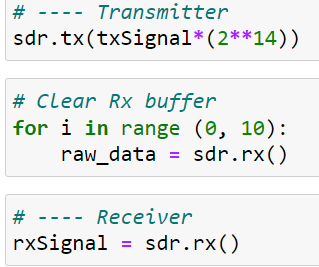


**3.** Repita los pasos anteriores pero ahora aumentando la potencia de la señal transmitida, esto es llevando el valor de la variable "TxAtten" al valor -70. Describa con sus propias palabras lo que observa en el histograma de la señal comparándola con lo anteriormente obtenido.

**4.** Configure el valor de la variable "ref" a un valor de 0.3 y repita los pasos anteriores. Que puede concluir del histograma obtenido de la señal recibida?. 

**5.** Modifique el código para enviar una hipotesis  H \in \{ -1,-0.3333,+0.3333,+1\}  con igual probabilidades. Muestre el histograma de la señal recibida por el SDR.  Describa con sus propias palabras lo que observa en la gráfica.
Tenga presente que si la cantidad de muestras de la señal a transmitir ha cambiado, debe eliminar el buffer Y volverlo a configurar para evitar errores de configuración. Las siguiente lineas de código muestra el procedimiento descripto:

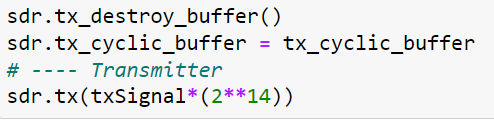

## Resolución Punto 1

Definición complementaría de las funciones de Python a utilizar

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
def plotSignal(signal, samplerate):
    # Configura una única figura para todos los subplots
    plt.figure(figsize=(20, 16), dpi=80, facecolor="w", edgecolor="k")
    
    #------------------------------- Componente I transmitida -------------------------------
    # Grafico la componente I en el tiempo
    plt.subplot(4, 1, 1)
    plt.plot(np.real(signal))
    plt.xlabel("n")
    plt.ylabel("Amplitud")
    plt.title("Componente en fase de la señal")
    plt.grid()
    
    # Grafico la componente I en la frecuencia
    # Se hace uso de magnitude_spectrum y del samplerate utilizado por el SDR
    plt.subplot(4, 1, 2)
    plt.magnitude_spectrum(np.real(signal), scale="dB", Fs=samplerate)
    plt.title("Espectro de Frecuencia de la Componente I")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud (dB)")
    plt.grid()
    
    #------------------------------- Componente Q transmitida -------------------------------
    # Grafico la componente Q en el tiempo
    plt.subplot(4, 1, 3)
    plt.plot(np.imag(signal))
    plt.xlabel("n")
    plt.ylabel("Amplitud")
    plt.title("Componente en cuadratura de la señal")
    plt.grid()
    
    # Grafico la componente Q en la frecuencia
    # Se hace uso de magnitude_spectrum y del samplerate utilizado por el SDR
    plt.subplot(4, 1, 4)
    plt.magnitude_spectrum(np.imag(signal),scale="dB", Fs=samplerate)
    plt.title("Espectro de Frecuencia de la Componente Q")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud (dB)")
    plt.grid()
    
    # Mostrar los graficos
    plt.tight_layout()
    plt.show()

In [ ]:
def media_var(signal):
    media = np.mean(signal)
    var = np.var(signal)
    return media, var

In [ ]:
def real_imag(signal):
    return np.real(signal), np.imag(signal)

In [ ]:
def plotSpect(signal,samplingRate):
    plt.subplots(figsize=(15, 3))
    plt.grid()
    plt.title("Espectro De Densidad De Potencia de de la Señal")
    plt.psd(signal, len(signal), samplingRate)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud (dB/Hz)")
    plt.show()

In [ ]:
def histograma(signal, parte, n):
    # Creación del histograma con n bins
    plt.figure(figsize=(15, 6))
    plt.hist(signal, bins=n, density = True, color='blue', alpha=0.7)
    plt.title("Histograma de la Parte " + parte + " de la Señal")
    plt.xticks(np.arange(-1.5, 1.6, step=0.1))
    plt.xlabel("Valor")
    plt.ylabel("Densidad De Probabilidad")
    plt.grid(True)
    plt.show()

In [ ]:

ref = 0.5
n = 100
z = np.random.uniform(size=n)
x =[1 if z[i]>ref else 0 for i in range(len(z)) ]
txSignal = (2*np.repeat(x ,2**4)-1)+1j*(2*np.repeat(x , 2**4)-1)

# Extrae las componentes en fase (I) y en cuadratura (Q)
I, Q = real_imag(txSignal)

### Grafico En Tiempo Y Frecuencia

Se realizaron gráficos, previamente procesados por funciones de Python, de la señal compleja. Tanto en el tiempo como en la frecuencía. 

In [ ]:
#Señal en el tiempo y la frecuencia
plotSignal(txSignal, n)

Se realizó una gráfica del espectro de densidad de potencia. Tanto del lado negativo, la parte imaginaria, como del positivo, la parte real,  con el fin de tener otra perspectiva.

In [ ]:
# Realiza gráficas en frecuencía utilizando la función plot.psd()
plotSpect(txSignal, n)

### Histogramas

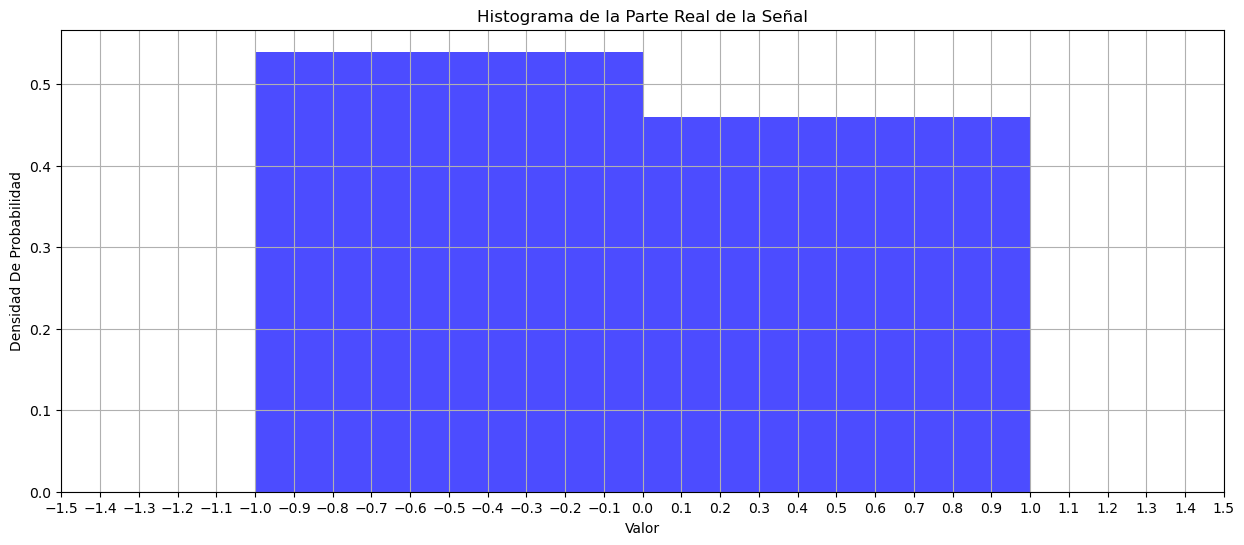

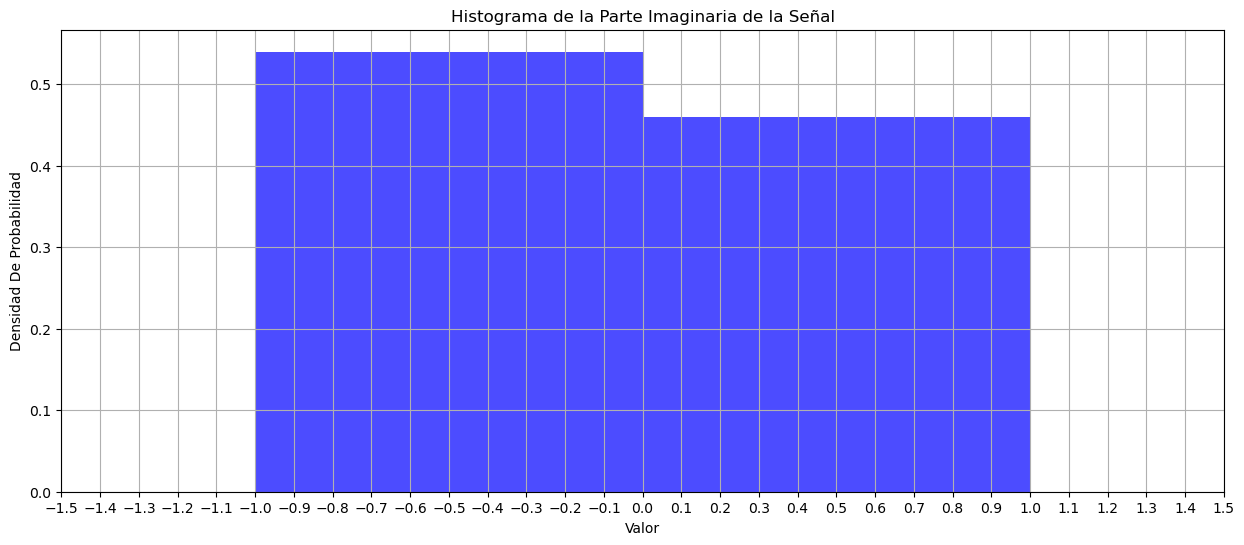

In [22]:
#Histograma de la parte real
histograma(I, "Real",2)
#Histograma de la parte real
histograma(Q, "Imaginaria",2)

### Observaciones

 - **Gráfica en el tiempo:** Se puede observar que la parte real e imaginaría de la señal generada son iguales. Ambas son una secuencía de numeros alternados entre -1 y 1.
 - **Gráficas en frecuencia:** En la gráfica de la frecuencía en relación con su magnitud, en dB, se ve con claridad unos semicirculos con irregularidades. Estos parecen un pulso cuadrado expresado mediante la serie de fourier. También, se ve que hay un pico en el origen de la gráfica. Al ver la gráfica del espectro de densidad de potencia se ve con claridad lo mencionado anteriormente. Hay una clara disminución de los picos de los semicirculos a medida que aumenta la frecuencia. Por ultimo, queda claro que ambas componentes de la señal son exactamente iguales y, por lo tanto, simetricas respecto al origen.
 - **Histograma:** Se puede ver que hay unicamente 2 valores posibles, que van desde -1 a 0 y de 0 a 1, con limites bien delimitados. Esto concuerda con el analisis previamente hecho de la gráfica en el tiempo. 

## Resolución Punto 2

In [ ]:
import adi
# Configuración de parámetros
uri = "ip:192.168.1.33"  # Reemplaza con la IP del dispositivo SDR.
sample_rate = 9e6  # Frecuencia de muestreo para RX y TX
tx_lo_freq = 650 * 1e6  # Reemplaza xx por el valor adecuado para la frecuencia de la portadora TX
tx_atten = -79  # Atenuación en dB para la ruta TX
tx_rf_bandwidth = 6e6  # Ancho de banda del filtro analógico TX

rx_lo_freq = tx_lo_freq  # Frecuencia de la portadora RX
gain_control_mode = "manual"  # Modo de control de ganancia para RX
rx_hardware_gain = 70  # Ganancia de hardware para RX
rx_rf_bandwidth = tx_rf_bandwidth  # Ancho de banda del filtro analógico RX

# Crear la instancia del dispositivo SDR con la URI
sdr = adi.Pluto(uri=uri)

# Configuración del dispositivo SDR
sdr.tx_lo = int(tx_lo_freq)
sdr.tx_sample_rate = int(sample_rate)
sdr.tx_rf_bandwidth = int(tx_rf_bandwidth)
sdr.tx_attenuation = int(tx_atten)
sdr.tx_cyclic_buffer = True

sdr.rx_lo = int(rx_lo_freq)
sdr.rx_sample_rate = int(sample_rate)
sdr.rx_rf_bandwidth = int(rx_rf_bandwidth)
sdr.rx_gain_control_mode = gain_control_mode
sdr.rx_hardwaregain = rx_hardware_gain
sdr.rx_buffer_size = len(txSignal)

In [ ]:
# Transmisión
sdr.tx(txSignal*(2**14))

# Limpiar el Rx buffer
for i in range(0, 10):
    raw_data = sdr.rx()
    
# Recepción
rxSignal_1 = sdr.rx()

In [ ]:
# Calcula la potencía de la señal recibida
potencia = np.mean(np.abs(rxSignal_1)**2)

# Normaliza la señal por unidad de potencia
norm_rxSignal_1 = rxSignal_1 / np.sqrt(potencia)

# Señal en el tiempo y la frecuencia
plotSignal(norm_rxSignal_1, int(sample_rate))

# Extrae las componentes en fase (I) y en cuadratura (Q)
I_1, Q_1 = real_imag(norm_rxSignal_1)
# Histograma de la parte real
histograma(I_1, "Real", 2)
# Histograma de la parte real
histograma(Q_1, "Imaginaria",2)


In [ ]:
# Elimina el buffer y lo vuelve a configurar
sdr.tx_destroy_buffer()
sdr.tx_cyclic_buffer = True

### Observaciones

 - Gráfica en el tiempo: se puede observar como la señal transmitida, al ser recibida, pierde claridad y se introduce ruido. Paso de ser una señal perfectamente cuadrada a tener muchas irregularidades y picos, que no corresponden a la forma original a la señal. Otra hecho a destacar es que las componentes, real e imaginaria, ahora no son perfectamente iguales, si no que existen discrepancias entre si.
 - Histograma: Como vemos, este gráfico sufrio leves modificaciones. En la parte real, se puede observar que la probabilidades mantuvieron una cierta fidelidad respecto a la señal original. A diferencia de la ultima mencionada, las barras del histograma no van desde -1 a 1 de forma perfecta, si no que van desde valores mayores a -1 y valores menores a 1, sin llegar a los mismos. Por ultimo, se destaca que la parte imaginaria muestra menos fidelidad que la parte real, alejandose de las probabilidades obtenidas en la señal transmitida, y que las densidades de probabilidad son mayores que las de la señal generada. Por ultimo, en este caso, los histogramas de las componentes no son exactamente iguales, sino que presentan ciertas discrepancias.

## Resolución Punto 3

In [ ]:
sdr.tx_attenuation = int(-70)
# Transmisión
sdr.tx(txSignal*(2**14))
# Limpiar el Rx buffer
for i in range(0, 10):
    raw_data = sdr.rx()
# Recepción
rxSignal_2 = sdr.rx()

In [ ]:
# Calcula la potencía de la señal recibida
potencia = np.mean(np.abs(rxSignal_2)**2)

# Normaliza la señal por unidad de potencia
norm_rxSignal_2 = rxSignal_2 / np.sqrt(potencia)

# Señal en el tiempo y la frecuencia
plotSignal(norm_rxSignal_2, int(sample_rate))

# Extrae las componentes en fase (I) y en cuadratura (Q)
I_2, Q_2 = real_imag(norm_rxSignal_2)
# Histograma de la parte real
histograma(I_2, "Real",2)
# Histograma de la parte real
histograma(Q_2, "Imaginaria",2)

In [ ]:
# Elimina el buffer y lo vuelve a configurar
sdr.tx_destroy_buffer()
sdr.tx_cyclic_buffer = True

### Observaciones

 - **Gráfica en el tiempo:** se puede mejorar una notable mejoría de la claridad de la imagen recibida, respecto al a caso anterior. Hay menos picos y menos irregularidades en las zonas planas de la señal. También, durante los cambios de valor, se ve que el estado transitorio es menor y se llega mucho más rapido a los valores esperados de las zonas estacionarias. Al diferencia del caso anterior, las componentes, la parte real e imaginaria, presentan mayores similitudes, sin llegar a ser exactamente iguales. 
 - **Histograma:** Como vemos, en este caso ambos histogramas presentan muchas similitudes al histograma de la señal generada y también a la señal previamente analizada. Las principales diferencias se encuentran en los valores de densidad de probabilidad, que acá son más altos a los de la señal original y anterior. Se ve que ninguno de las dos barras llegan a los valores -1 y 1, de manera similar al caso previo. Por ultimo, a diferencia del caso anterior, los histogramas de ambas componentes son muy parecidos.

## Resolución Punto 4

In [36]:
ref_1 = 0.3
n_1 = 100
z_1 = np.random.uniform(size=n_1)
x_1 =[1 if z_1[i]>ref_1 else 0 for i in range(len(z_1)) ]
txSignal_1 = (2*np.repeat(x_1 ,2**4)-1)+1j*(2*np.repeat(x_1 , 2**4)-1)

# Extrae las componentes en fase (I) y en cuadratura (Q)
I_1, Q_1 = real_imag(txSignal_1)

### Grafico En Tiempo Y Frecuencia

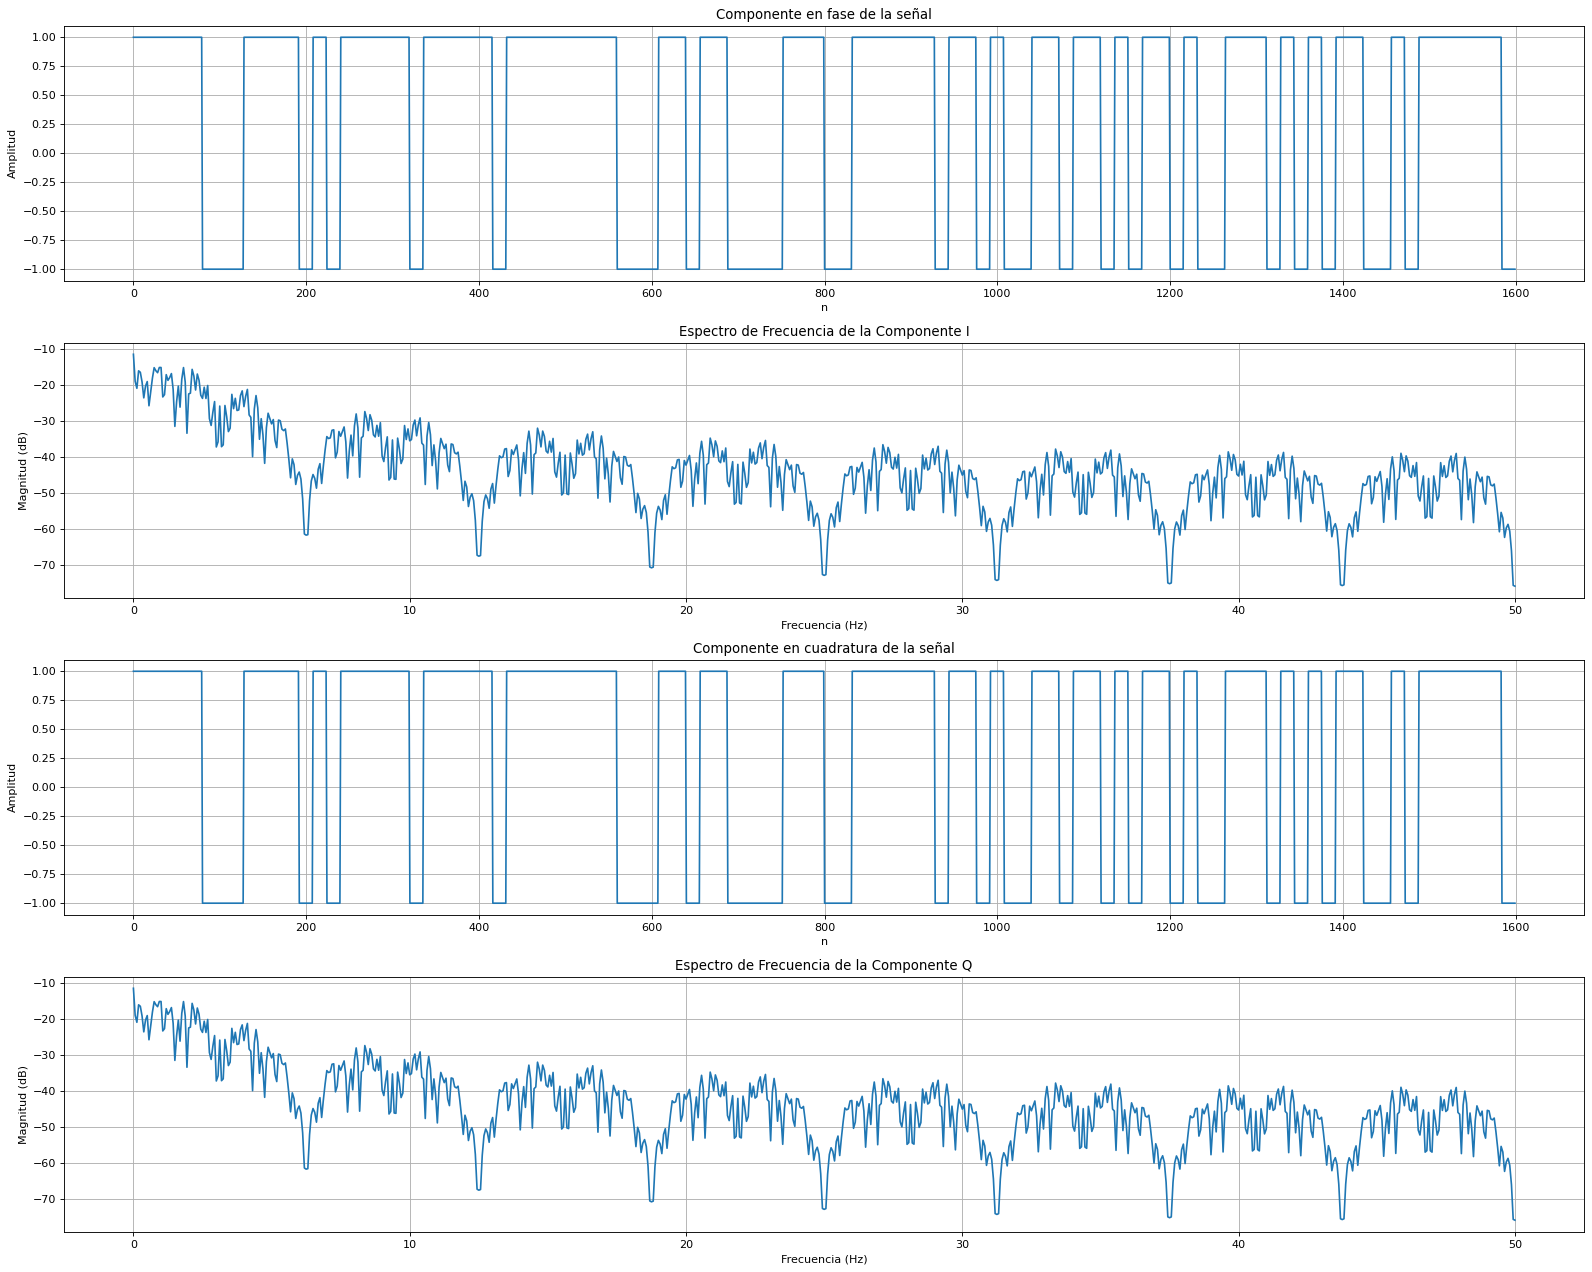

In [37]:
#Señal en el tiempo y la frecuencia
plotSignal(txSignal_1, n_1)

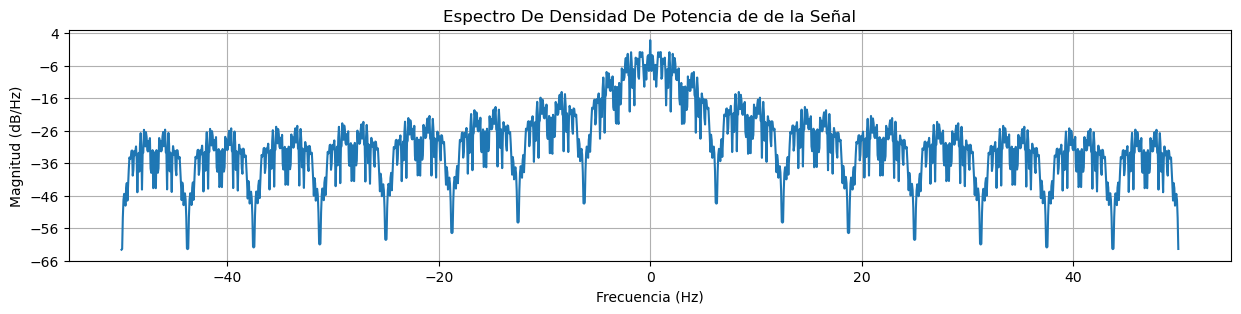

In [38]:
# Realiza gráficas en frecuencía utilizando la función plot.psd()
plotSpect(txSignal_1, n_1)

### Histogramas

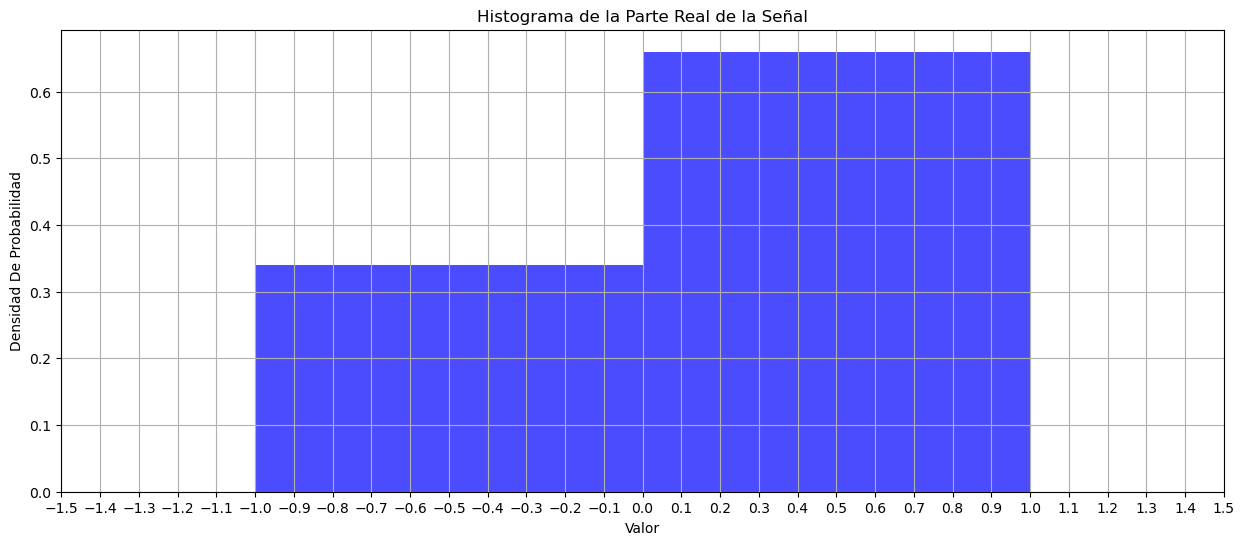

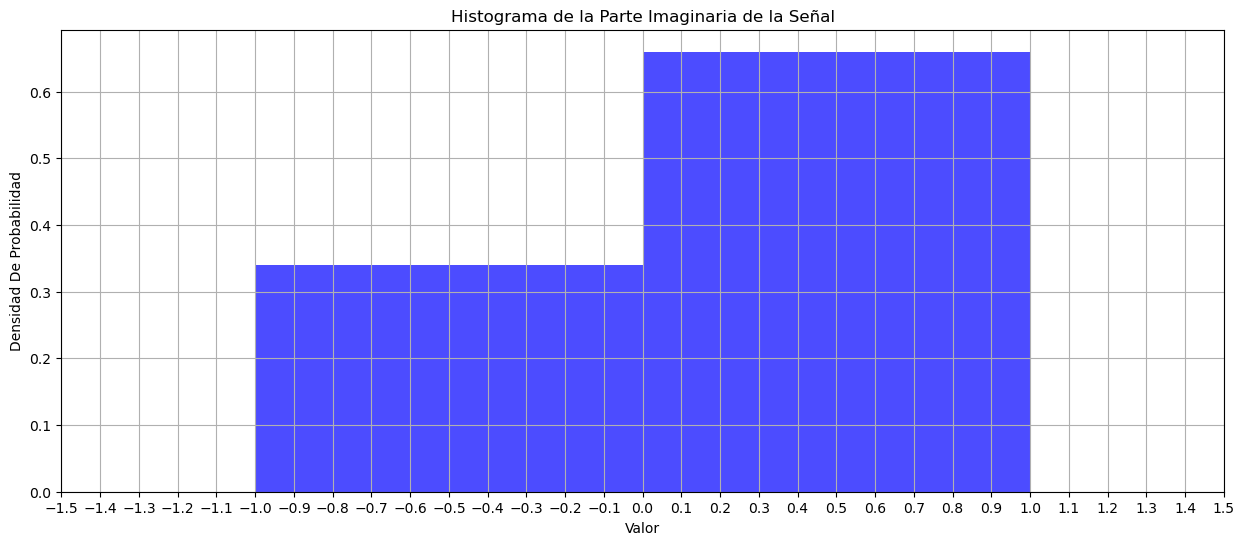

In [39]:
#Histograma de la parte real
histograma(I_1, "Real",2)
#Histograma de la parte real
histograma(Q_1, "Imaginaria",2)

In [ ]:
sdr.tx_attenuation = int(-70)
# Transmisión
sdr.tx(txSignal_1*(2**14))
# Limpiar el Rx buffer
for i in range(0, 10):
    raw_data = sdr.rx()
# Recepción
rxSignal_3 = sdr.rx()

In [ ]:
# Calcula la potencía de la señal recibida
potencia_1 = np.mean(np.abs(rxSignal_3)**2)

# Normaliza la señal por unidad de potencia
norm_rxSignal_3 = rxSignal_3 / np.sqrt(potencia)

# Señal en el tiempo y la frecuencia
plotSignal(norm_rxSignal_3, int(sample_rate))

# Extrae las componentes en fase (I) y en cuadratura (Q)
I_2, Q_2 = real_imag(norm_rxSignal_3)
# Histograma de la parte real
histograma(I_2, "Real",2)
# Histograma de la parte real
histograma(Q_2, "Imaginaria",2)

In [ ]:
# Elimina el buffer y lo vuelve a configurar
sdr.tx_destroy_buffer()
sdr.tx_cyclic_buffer = True

## Resolución Punto 5

In [ ]:
n_2 = 100

# Generamos valores aleatorios para la hipótesis H con igual probabilidad
h = np.array([-1, -0.3333, 0.3333, 1])
txSignal_2 = np.random.choice(h, size=100)

In [ ]:
sdr.tx_attenuation = int(-70)
# Transmisión
sdr.tx(txSignal_2*(2**14))
# Limpiar el Rx buffer
for i in range(0, 10):
    raw_data = sdr.rx()
# Recepción
rxSignal_4 = sdr.rx()

In [ ]:
# Calcula la potencía de la señal recibida
potencia_2 = np.mean(np.abs(rxSignal_4)**2)

# Normaliza la señal por unidad de potencia
norm_rxSignal_4 = rxSignal_4 / np.sqrt(potencia)

# Señal en el tiempo y la frecuencia
plotSignal(norm_rxSignal_4, int(sample_rate))

# Extrae las componentes en fase (I) y en cuadratura (Q)
I_3, Q_3 = real_imag(norm_rxSignal_4)
# Histograma de la parte real
histograma(I_3, "Real",2)
# Histograma de la parte real
histograma(Q_3, "Imaginaria",2)